<a href="https://colab.research.google.com/github/RodrigoSoares0/SIN_Fuzzy_viabilidade_de_lancamentos_imobiliarios/blob/main/sistema_fuzzy_imobiliario_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistema Fuzzy de Viabilidade de Lançamentos Imobiliários
Notebook organizado.

In [ ]:
%pip install -q numpy scipy matplotlib scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.9 MB/s eta 0:00:00


# Sistema Fuzzy de Viabilidade de Lançamentos Imobiliários
Notebook organizado por seções.


In [ ]:
# -*- coding: utf-8 -*-
"""
VIABILIDADE E ATRATIVIDADE DE LANÇAMENTOS IMOBILIÁRIOS
======================================================
Sistema de Suporte à Decisão baseado em Lógica Fuzzy.

Arquitetura (hierárquica, para evitar explosão combinatória de 3^8 regras):

    ENTRADAS (8)                     SUBSISTEMAS MAMDANI            SAÍDA FINAL
    ------------                     -------------------            -----------
    INCC acumulado  ─┐
    Selic / CDI     ─┴─────────────► [A] Atratividade Macro ─┐
    VSO             ─┐                                       │
    Estoque concorr.─┼─────────────► [B] Força de Mercado  ──┼──► MAMDANI FINAL
    Preço m² relat. ─┘                                       │    Viabilidade:
    Renda média     ─┐                                       │    Risco Crítico /
    Proximidade     ─┼─────────────► [C] Qualidade Demanda ──┘    Moderada / Alta
    Inadimplência   ─┘

    + Simulação de demanda com Distribuição de POISSON (fator humano)
    + Modelo TSK (Takagi-Sugeno-Kang) identificado via FUZZY C-MEANS
      para projeção numérica do VGV (Valor Geral de Vendas)

Autores: Pedro Andrade Pereira Leão | Pedro Detoni Pereira | Rodrigo da Silva Soares
Bibliotecas: numpy, scikit-fuzzy, matplotlib, scipy
"""

import itertools
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

RNG = np.random.default_rng(42)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})



## 1. VARIÁVEIS DE ENTRADA (universos e funções de pertinência)


##    Curvas suaves (trapezoidais/triangulares) => "economia sem quedas bruscas"


In [ ]:

def _var(nome, universo):
    return ctrl.Antecedent(universo, nome)



## --- Bloco Macroeconômico -----------------------------------------------


In [ ]:
incc = _var("incc", np.arange(0, 15.01, 0.05))            # % acumulado 12m
incc["baixo"]    = fuzz.trapmf(incc.universe, [0, 0, 3, 6])
incc["moderado"] = fuzz.trimf(incc.universe,  [4, 7, 10])
incc["alto"]     = fuzz.trapmf(incc.universe, [8, 10, 15, 15])

selic = _var("selic", np.arange(2, 20.01, 0.05))          # % a.a.
selic["baixa"]    = fuzz.trapmf(selic.universe, [2, 2, 4, 8])
selic["moderada"] = fuzz.trimf(selic.universe,  [6, 10, 14])
selic["alta"]     = fuzz.trapmf(selic.universe, [11.5, 15, 20, 20])



## --- Bloco de Mercado -----------------------------------------------------


In [ ]:
vso = _var("vso", np.arange(0, 40.01, 0.1))               # % trimestral
vso["baixa"] = fuzz.trapmf(vso.universe, [0, 0, 5, 10])
vso["media"] = fuzz.trimf(vso.universe,  [6, 14, 22])
vso["alta"]  = fuzz.trapmf(vso.universe, [18, 25, 40, 40])

estoque = _var("estoque", np.arange(0, 36.01, 0.1))       # meses de oferta
estoque["baixo"] = fuzz.trapmf(estoque.universe, [0, 0, 6, 12])
estoque["medio"] = fuzz.trimf(estoque.universe,  [8, 18, 26])
estoque["alto"]  = fuzz.trapmf(estoque.universe, [22, 30, 36, 36])

preco_rel = _var("preco_rel", np.arange(0.70, 1.301, 0.005))  # razão vs mercado
preco_rel["abaixo"]   = fuzz.trapmf(preco_rel.universe, [0.70, 0.70, 0.88, 0.97])
preco_rel["alinhado"] = fuzz.trimf(preco_rel.universe,  [0.91, 1.00, 1.09])
preco_rel["acima"]    = fuzz.trapmf(preco_rel.universe, [1.03, 1.12, 1.30, 1.30])



## --- Bloco de Demanda -----------------------------------------------------


In [ ]:
renda = _var("renda", np.arange(1, 30.01, 0.1))           # R$ mil / mês
renda["baixa"] = fuzz.trapmf(renda.universe, [1, 1, 3, 7])
renda["media"] = fuzz.trimf(renda.universe,  [4, 10, 16])
renda["alta"]  = fuzz.trapmf(renda.universe, [13, 20, 30, 30])

proximidade = _var("proximidade", np.arange(0, 10.01, 0.05))  # score 0-10
proximidade["distante"] = fuzz.trapmf(proximidade.universe, [0, 0, 2.5, 4])
proximidade["media"]    = fuzz.trimf(proximidade.universe,  [2.5, 5, 7.5])
proximidade["proxima"]  = fuzz.trapmf(proximidade.universe, [6, 8.5, 10, 10])

distrato = _var("distrato", np.arange(0, 30.01, 0.1))     # % inadimpl./distrato
distrato["baixo"] = fuzz.trapmf(distrato.universe, [0, 0, 4, 9])
distrato["medio"] = fuzz.trimf(distrato.universe,  [6, 13, 20])
distrato["alto"]  = fuzz.trapmf(distrato.universe, [16, 22, 30, 30])



## 2. SUBSISTEMAS MAMDANI (saídas intermediárias em escala 0-10)


In [ ]:

def _saida(nome):
    s = ctrl.Consequent(np.arange(0, 10.01, 0.05), nome)
    s["ruim"]  = fuzz.trapmf(s.universe, [0, 0, 2.5, 4.5])
    s["media"] = fuzz.trimf(s.universe,  [3.5, 5, 6.5])
    s["boa"]   = fuzz.trapmf(s.universe, [5.5, 7.5, 10, 10])
    return s

def _regras_por_score(antecedentes, termos_bons, consequente, limites=None):
    """Gera regras automaticamente: cada termo recebe score 0/1/2 conforme sua
    posição na lista `termos_bons` (do pior para o melhor). A soma dos scores
    define o termo de saída — evita escrever 27 regras à mão."""
    regras = []
    n = len(antecedentes)
    if limites is None:                      # limiares p/ soma em [0, 2n]
        limites = (0.40 * 2 * n, 0.68 * 2 * n)
    for combo in itertools.product(range(3), repeat=n):
        soma = sum(combo)
        termo = ("ruim" if soma < limites[0]
                 else "media" if soma < limites[1] else "boa")
        cond = None
        for var, idx in zip(antecedentes, combo):
            c = var[termos_bons[var.label][idx]]
            cond = c if cond is None else cond & c
        regras.append(ctrl.Rule(cond, consequente[termo]))
    return regras



## --- [A] Atratividade Macroeconômica (INCC + Selic) ----------------------


In [ ]:
macro_out = _saida("macro")
ordem = {  # termos do PIOR (score 0) para o MELHOR (score 2)
    "incc":  ["alto", "moderado", "baixo"],
    "selic": ["alta", "moderada", "baixa"],
}
sys_macro = ctrl.ControlSystem(_regras_por_score([incc, selic], ordem, macro_out))



## --- [B] Força de Mercado (VSO + Estoque + Preço relativo) ---------------


In [ ]:
mercado_out = _saida("mercado")
ordem_b = {
    "vso":       ["baixa", "media", "alta"],
    "estoque":   ["alto", "medio", "baixo"],
    "preco_rel": ["acima", "alinhado", "abaixo"],
}
sys_mercado = ctrl.ControlSystem(
    _regras_por_score([vso, estoque, preco_rel], ordem_b, mercado_out))



## --- [C] Qualidade da Demanda (Renda + Proximidade + Distrato) -----------


In [ ]:
demanda_out = _saida("demanda")
ordem_c = {
    "renda":       ["baixa", "media", "alta"],
    "proximidade": ["distante", "media", "proxima"],
    "distrato":    ["alto", "medio", "baixo"],
}
sys_demanda = ctrl.ControlSystem(
    _regras_por_score([renda, proximidade, distrato], ordem_c, demanda_out))



## --- MAMDANI FINAL: Viabilidade do Lançamento -----------------------------


In [ ]:
macro_in   = _var("macro_in",   np.arange(0, 10.01, 0.05))
mercado_in = _var("mercado_in", np.arange(0, 10.01, 0.05))
demanda_in = _var("demanda_in", np.arange(0, 10.01, 0.05))
for v in (macro_in, mercado_in, demanda_in):
    v["ruim"]  = fuzz.trapmf(v.universe, [0, 0, 2.5, 4.5])
    v["media"] = fuzz.trimf(v.universe,  [3.5, 5, 6.5])
    v["boa"]   = fuzz.trapmf(v.universe, [5.5, 7.5, 10, 10])

viabilidade = ctrl.Consequent(np.arange(0, 10.01, 0.05), "viabilidade")
viabilidade["risco_critico"] = fuzz.trapmf(viabilidade.universe, [0, 0, 2.5, 4.5])
viabilidade["moderada"]      = fuzz.trimf(viabilidade.universe,  [3.5, 5, 6.5])
viabilidade["alta"]          = fuzz.trapmf(viabilidade.universe, [5.5, 7.5, 10, 10])

_MAPA_FINAL = {"ruim": "risco_critico", "media": "moderada", "boa": "alta"}
regras_finais = []
for combo in itertools.product(range(3), repeat=3):
    soma = sum(combo)
    interm = "ruim" if soma < 2.4 else "media" if soma < 4.1 else "boa"
    termos = ["ruim", "media", "boa"]
    cond = (macro_in[termos[combo[0]]] & mercado_in[termos[combo[1]]]
            & demanda_in[termos[combo[2]]])
    regras_finais.append(ctrl.Rule(cond, viabilidade[_MAPA_FINAL[interm]]))
sys_final = ctrl.ControlSystem(regras_finais)


def avaliar_lancamento(entradas: dict) -> dict:
    """Executa a cascata Mamdani completa para um cenário de lançamento."""
    sm = ctrl.ControlSystemSimulation(sys_macro)
    sm.input["incc"], sm.input["selic"] = entradas["incc"], entradas["selic"]
    sm.compute()
    macro = sm.output["macro"]

    sk = ctrl.ControlSystemSimulation(sys_mercado)
    sk.input["vso"] = entradas["vso"]
    sk.input["estoque"] = entradas["estoque"]
    sk.input["preco_rel"] = entradas["preco_rel"]
    sk.compute()
    mercado = sk.output["mercado"]

    sd = ctrl.ControlSystemSimulation(sys_demanda)
    sd.input["renda"] = entradas["renda"]
    sd.input["proximidade"] = entradas["proximidade"]
    sd.input["distrato"] = entradas["distrato"]
    sd.compute()
    demanda = sd.output["demanda"]

    sf = ctrl.ControlSystemSimulation(sys_final)
    sf.input["macro_in"], sf.input["mercado_in"], sf.input["demanda_in"] = \
        macro, mercado, demanda
    sf.compute()
    score = sf.output["viabilidade"]

    graus = {t: fuzz.interp_membership(viabilidade.universe,
                                       viabilidade[t].mf, score)
             for t in ("risco_critico", "moderada", "alta")}
    rotulo = {"risco_critico": "RISCO CRÍTICO",
              "moderada": "VIABILIDADE MODERADA",
              "alta": "VIABILIDADE ALTA"}[max(graus, key=graus.get)]
    return {"macro": macro, "mercado": mercado, "demanda": demanda,
            "score": score, "rotulo": rotulo, "graus": graus}



## 3. FATOR HUMANO — SIMULAÇÃO DE VENDAS COM DISTRIBUIÇÃO DE POISSON


In [ ]:

def simular_vendas_poisson(score_viabilidade, unidades=120, meses=24,
                            lambda_base=9.0, n_cenarios=300):
    """Chegada de compradores ~ Poisson(λ_t). O λ é modulado pela viabilidade
    fuzzy e por sazonalidade, capturando choques de demanda e meses parados."""
    lam = lambda_base * (0.35 + 0.13 * score_viabilidade)      # nível médio
    sazonal = 1 + 0.25 * np.sin(2 * np.pi * (np.arange(meses) + 2) / 12)
    trajetorias = np.zeros((n_cenarios, meses), dtype=int)
    for c in range(n_cenarios):
        estoque_restante = unidades
        for t in range(meses):
            vendas = min(RNG.poisson(lam * sazonal[t]), estoque_restante)
            trajetorias[c, t] = vendas
            estoque_restante -= vendas
    acumulado = trajetorias.cumsum(axis=1)
    return trajetorias, acumulado, lam



## 4. MODELO TSK VIA FUZZY C-MEANS — PROJEÇÃO DE VGV (R$ milhões)


In [ ]:

def gerar_dataset_vgv(n=400):
    """Dataset sintético de lançamentos: entradas de mercado -> VGV realizado.
    (Na prática seria o histórico da incorporadora.)"""
    vso_h   = RNG.uniform(2, 38, n)          # % trimestral
    renda_h = RNG.uniform(2, 28, n)          # R$ mil
    preco_h = RNG.uniform(0.72, 1.28, n)     # preço relativo
    selic_h = RNG.uniform(2.5, 19, n)        # % a.a.

    unidades = 120
    preco_medio_unid = 0.45 * (renda_h / 10) ** 0.9 * preco_h      # R$ mi/unid
    absorcao = (0.30 + 0.55 * (vso_h / 40) - 0.20 * (selic_h - 10) / 10
                - 0.25 * np.maximum(preco_h - 1.0, 0))
    absorcao = np.clip(absorcao + RNG.normal(0, 0.05, n), 0.05, 1.0)
    vgv = unidades * preco_medio_unid * absorcao
    vgv *= 1 + RNG.normal(0, 0.06, n)                               # ruído
    X = np.column_stack([vso_h, renda_h, preco_h, selic_h])
    return X, vgv


class ModeloTSK:
    """TSK de 1ª ordem: regras extraídas por Fuzzy C-Means; consequentes
    lineares ajustados por mínimos quadrados ponderados pela pertinência."""

    def __init__(self, n_clusters=3, m=2.0):
        self.c, self.m = n_clusters, m

    def treinar(self, X, y):
        self.x_mean, self.x_std = X.mean(0), X.std(0)
        Xn = (X - self.x_mean) / self.x_std
        cntr, u, *_ , self.fpc = fuzz.cluster.cmeans(
            Xn.T, self.c, self.m, error=1e-6, maxiter=2000, seed=42)
        self.centros = cntr
        Xa = np.column_stack([X, np.ones(len(X))])   # coluna de bias
        self.coefs = np.zeros((self.c, Xa.shape[1]))
        for i in range(self.c):                       # WLS por regra
            W = np.diag(u[i] ** self.m)
            self.coefs[i] = np.linalg.lstsq(
                np.sqrt(W) @ Xa, np.sqrt(np.diag(W)) * y, rcond=None)[0]
        return self

    def _pertinencias(self, X):
        Xn = ((X - self.x_mean) / self.x_std).T
        u, *_ = fuzz.cluster.cmeans_predict(
            Xn, self.centros, self.m, error=1e-6, maxiter=2000)
        return u                                       # shape (c, n)

    def prever(self, X):
        u = self._pertinencias(np.atleast_2d(X))
        Xa = np.column_stack([np.atleast_2d(X), np.ones(len(np.atleast_2d(X)))])
        y_regras = self.coefs @ Xa.T                   # (c, n)
        return (u * y_regras).sum(0) / u.sum(0), u



## 5. GRÁFICOS


In [ ]:

def plot_pertinencias():
    vars_ = [(incc, "INCC acumulado (%)"), (selic, "Selic (% a.a.)"),
             (vso, "VSO (% trim.)"), (renda, "Renda média (R$ mil)"),
             (estoque, "Estoque concorrentes (meses)"),
             (preco_rel, "Preço m² relativo"),
             (proximidade, "Proximidade a polos (0-10)"),
             (distrato, "Inadimplência/Distrato (%)")]
    fig, axes = plt.subplots(4, 2, figsize=(11, 12))
    for ax, (v, titulo) in zip(axes.flat, vars_):
        for termo in v.terms:
            ax.plot(v.universe, v[termo].mf, label=termo, lw=2)
        ax.set_title(titulo, fontweight="bold")
        ax.set_ylabel("μ(x)"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
    fig.suptitle("Funções de Pertinência — Variáveis de Entrada",
                 fontsize=13, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig("mf_entradas.png"); plt.show(); plt.close(fig)


def plot_saida_final(res):
    fig, ax = plt.subplots(figsize=(8, 4))
    cores = {"risco_critico": "#c0392b", "moderada": "#e6a817", "alta": "#27ae60"}
    for t in viabilidade.terms:
        ax.plot(viabilidade.universe, viabilidade[t].mf,
                label=t.replace("_", " "), lw=2, color=cores[t])
        ax.fill_between(viabilidade.universe, viabilidade[t].mf,
                        alpha=0.08, color=cores[t])
    ax.axvline(res["score"], color="k", ls="--", lw=2,
               label=f"cenário = {res['score']:.2f}")
    ax.set_title(f"Viabilidade do Lançamento → {res['rotulo']}",
                 fontweight="bold")
    ax.set_xlabel("score de viabilidade"); ax.set_ylabel("μ(x)")
    ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig("saida_viabilidade.png"); plt.show(); plt.close(fig)


def plot_superficie():
    grade = np.linspace(0, 10, 25)
    Zs = {}
    sim = ctrl.ControlSystemSimulation(sys_final, flush_after_run=len(grade)**2 + 1)
    for dem in (2.0, 8.0):
        Z = np.zeros((len(grade), len(grade)))
        for i, ma in enumerate(grade):
            for j, me in enumerate(grade):
                sim.input["macro_in"], sim.input["mercado_in"] = ma, me
                sim.input["demanda_in"] = dem
                sim.compute()
                Z[i, j] = sim.output["viabilidade"]
        Zs[dem] = Z
    Ma, Me = np.meshgrid(grade, grade, indexing="ij")
    fig = plt.figure(figsize=(12, 5))
    for k, (dem, Z) in enumerate(Zs.items(), 1):
        ax = fig.add_subplot(1, 2, k, projection="3d")
        ax.plot_surface(Ma, Me, Z, cmap="RdYlGn", edgecolor="none")
        ax.set_xlabel("Macro"); ax.set_ylabel("Mercado")
        ax.set_zlabel("Viabilidade")
        ax.set_title(f"Demanda fixa = {dem:.0f}", fontweight="bold")
    fig.suptitle("Superfície de Decisão — Mamdani Final", fontsize=13,
                 fontweight="bold")
    fig.tight_layout(); fig.savefig("superficie_viabilidade.png"); plt.show(); plt.close(fig)


def plot_poisson(traj, acum, lam, unidades):
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
    meses = np.arange(1, traj.shape[1] + 1)
    a1.bar(meses, traj[0], color="#1f3a6e", alpha=0.85)
    a1.axhline(lam, color="#e6a817", ls="--", lw=2, label=f"λ médio ≈ {lam:.1f}")
    a1.set_title("Vendas mensais — 1 cenário Poisson", fontweight="bold")
    a1.set_xlabel("mês"); a1.set_ylabel("unidades vendidas")
    a1.legend(); a1.grid(alpha=0.3)

    p10, p50, p90 = np.percentile(acum, [10, 50, 90], axis=0)
    a2.fill_between(meses, p10, p90, alpha=0.25, color="#1f3a6e",
                    label="faixa P10–P90")
    a2.plot(meses, p50, color="#1f3a6e", lw=2, label="mediana")
    a2.axhline(unidades, color="#c0392b", ls="--", label="estoque total")
    a2.set_title(f"Absorção acumulada ({acum.shape[0]} cenários)",
                 fontweight="bold")
    a2.set_xlabel("mês"); a2.set_ylabel("unidades acumuladas")
    a2.legend(); a2.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig("simulacao_poisson.png"); plt.show(); plt.close(fig)


def plot_tsk(modelo, X, y, y_pred):
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.8))
    u = modelo._pertinencias(X)
    cluster = u.argmax(0)
    sc = a1.scatter(X[:, 0], y, c=cluster, cmap="viridis", s=14, alpha=0.7)
    a1.set_title("Clusters Fuzzy C-Means (proj. VSO × VGV)", fontweight="bold")
    a1.set_xlabel("VSO (%)"); a1.set_ylabel("VGV (R$ mi)")
    plt.colorbar(sc, ax=a1, label="regra TSK"); a1.grid(alpha=0.3)

    a2.scatter(y, y_pred, s=14, alpha=0.6, color="#1f3a6e")
    lim = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
    a2.plot(lim, lim, "r--", lw=1.5)
    rmse = np.sqrt(np.mean((y - y_pred) ** 2))
    r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2)
    a2.set_title(f"TSK: real × previsto  (R²={r2:.3f}, RMSE={rmse:.2f})",
                 fontweight="bold")
    a2.set_xlabel("VGV real (R$ mi)"); a2.set_ylabel("VGV previsto (R$ mi)")
    a2.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig("tsk_vgv.png"); plt.show(); plt.close(fig)



## 6. ESTUDO DE CASO


 SISTEMA FUZZY DE VIABILIDADE DE LANÇAMENTOS IMOBILIÁRIOS

▶ Cenário FAVORÁVEL
   entradas: {'incc': 3.2, 'selic': 7.0, 'vso': 26, 'estoque': 8, 'preco_rel': 0.95, 'renda': 18, 'proximidade': 8.5, 'distrato': 4}
   Atratividade Macro : 7.87 / 10
   Força de Mercado   : 7.96 / 10
   Qualidade Demanda  : 8.08 / 10
   VIABILIDADE (Mamdani): 8.20 / 10  →  VIABILIDADE ALTA

▶ Cenário INTERMEDIÁRIO
   entradas: {'incc': 6.8, 'selic': 11.5, 'vso': 14, 'estoque': 17, 'preco_rel': 1.02, 'renda': 9, 'proximidade': 5.5, 'distrato': 11}
   Atratividade Macro : 5.00 / 10
   Força de Mercado   : 5.00 / 10
   Qualidade Demanda  : 5.00 / 10
   VIABILIDADE (Mamdani): 5.00 / 10  →  VIABILIDADE MODERADA

▶ Cenário ADVERSO
   entradas: {'incc': 11.5, 'selic': 16.5, 'vso': 6, 'estoque': 28, 'preco_rel': 1.18, 'renda': 4.5, 'proximidade': 2.5, 'distrato': 21}
   Atratividade Macro : 1.80 / 10
   Força de Mercado   : 1.90 / 10
   Qualidade Demanda  : 1.95 / 10
   VIABILIDADE (Mamdani): 1.80 / 10  →  RISCO CR

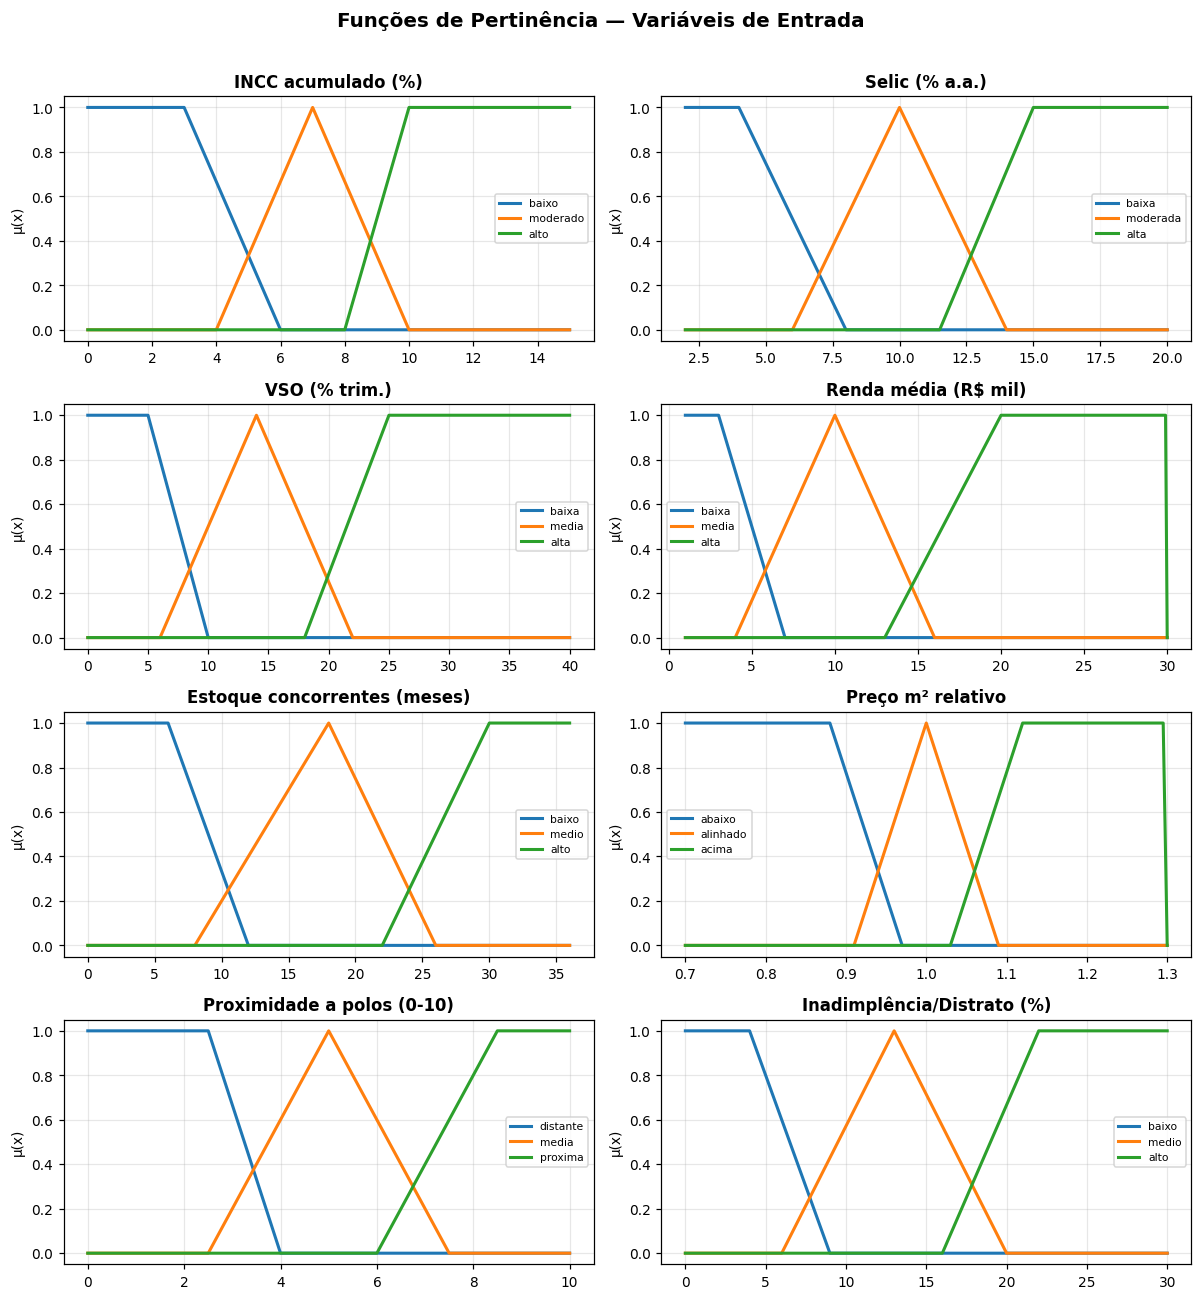

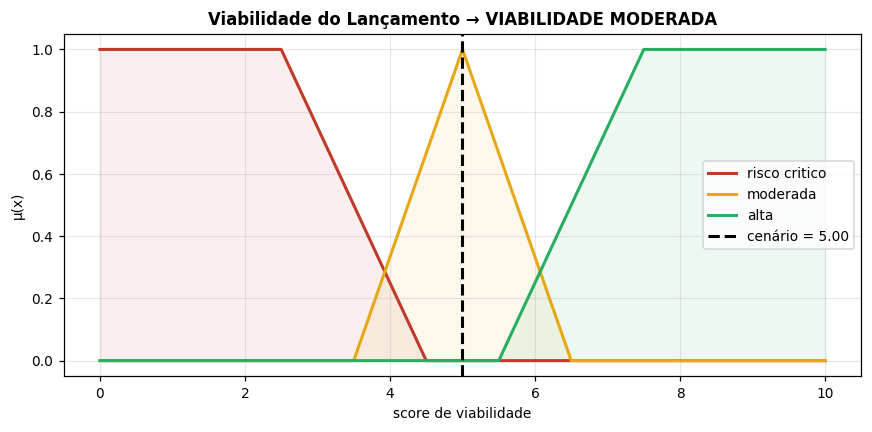

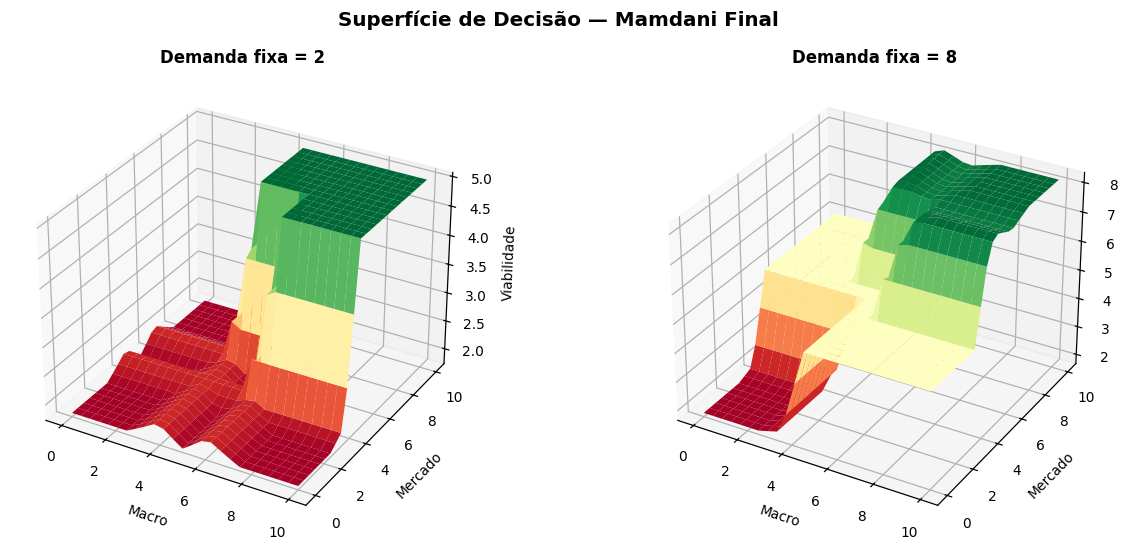

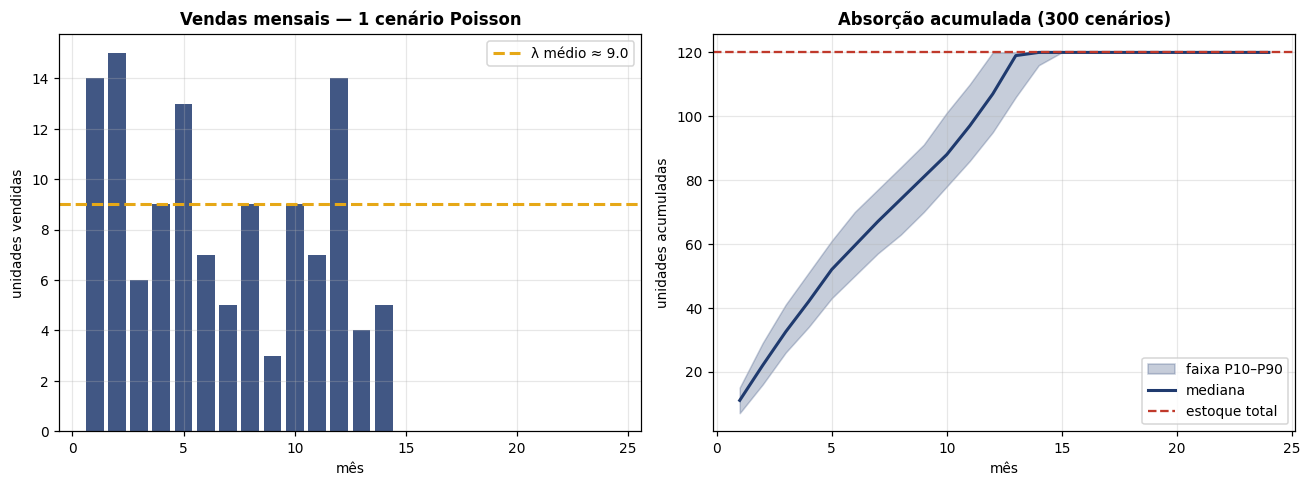

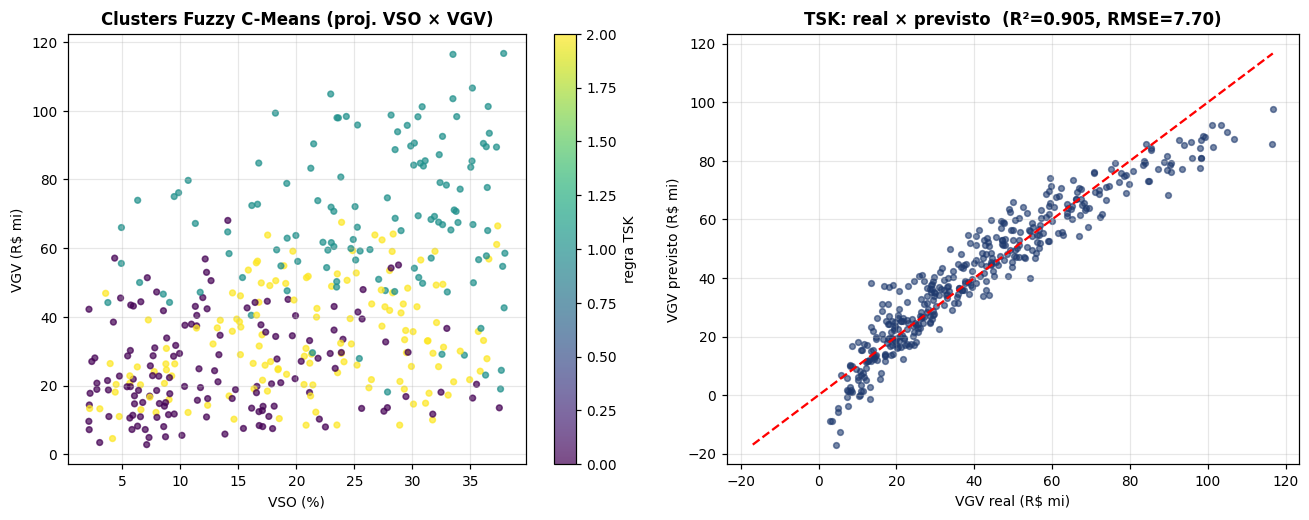


✔ Gráficos salvos: mf_entradas.png, saida_viabilidade.png, superficie_viabilidade.png, simulacao_poisson.png, tsk_vgv.png


In [ ]:

if __name__ == "__main__":
    cenarios = {
        "Cenário FAVORÁVEL": dict(incc=3.2, selic=7.0, vso=26, estoque=8,
                                  preco_rel=0.95, renda=18, proximidade=8.5,
                                  distrato=4),
        "Cenário INTERMEDIÁRIO": dict(incc=6.8, selic=11.5, vso=14, estoque=17,
                                      preco_rel=1.02, renda=9, proximidade=5.5,
                                      distrato=11),
        "Cenário ADVERSO": dict(incc=11.5, selic=16.5, vso=6, estoque=28,
                                preco_rel=1.18, renda=4.5, proximidade=2.5,
                                distrato=21),
    }

    print("=" * 74)
    print(" SISTEMA FUZZY DE VIABILIDADE DE LANÇAMENTOS IMOBILIÁRIOS")
    print("=" * 74)

    resultados = {}
    for nome, ent in cenarios.items():
        r = avaliar_lancamento(ent)
        resultados[nome] = r
        print(f"\n▶ {nome}")
        print(f"   entradas: {ent}")
        print(f"   Atratividade Macro : {r['macro']:.2f} / 10")
        print(f"   Força de Mercado   : {r['mercado']:.2f} / 10")
        print(f"   Qualidade Demanda  : {r['demanda']:.2f} / 10")
        print(f"   VIABILIDADE (Mamdani): {r['score']:.2f} / 10  →  {r['rotulo']}")

    # --- Poisson no cenário intermediário --------------------------------
    UNIDADES = 120
    r_mid = resultados["Cenário INTERMEDIÁRIO"]
    traj, acum, lam = simular_vendas_poisson(r_mid["score"], unidades=UNIDADES)
    meses_p50 = np.argmax(np.percentile(acum, 50, axis=0) >= UNIDADES * 0.9)
    meses_p50 = meses_p50 + 1 if meses_p50 > 0 else ">24"
    print(f"\n▶ Simulação Poisson (cenário intermediário, {UNIDADES} unidades)")
    print(f"   λ efetivo ≈ {lam:.1f} clientes-compradores/mês")
    print(f"   Mediana p/ vender 90% do estoque: {meses_p50} meses")

    # --- TSK / Fuzzy C-Means ---------------------------------------------
    X, y = gerar_dataset_vgv()
    tsk = ModeloTSK(n_clusters=3).treinar(X, y)
    y_pred, _ = tsk.prever(X)
    r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2)
    print(f"\n▶ Modelo TSK (Fuzzy C-Means, 3 regras)  |  FPC={tsk.fpc:.3f}  R²={r2:.3f}")
    for nome, ent in cenarios.items():
        x_novo = np.array([[ent["vso"], ent["renda"],
                            ent["preco_rel"], ent["selic"]]])
        vgv_prev, _ = tsk.prever(x_novo)
        print(f"   VGV projetado — {nome:<24s}: R$ {vgv_prev[0]:7.2f} milhões")

    print("\n▶ Consequentes lineares das regras TSK "
          "(VGV = a1·VSO + a2·Renda + a3·PreçoRel + a4·Selic + b):")
    for i, c in enumerate(tsk.coefs, 1):
        print(f"   Regra {i}: a={np.round(c[:-1], 3)}  b={c[-1]:.2f}")

    # --- Gráficos ----------------------------------------------------------
    plot_pertinencias()
    plot_saida_final(resultados["Cenário INTERMEDIÁRIO"])
    plot_superficie()
    plot_poisson(traj, acum, lam, UNIDADES)
    plot_tsk(tsk, X, y, y_pred)
    print("\n✔ Gráficos salvos: mf_entradas.png, saida_viabilidade.png, "
          "superficie_viabilidade.png, simulacao_poisson.png, tsk_vgv.png")
